# Iowa historical-weather and TaiESM1 validation

Compare six population-weighted weather variables, raw TELL load, wind CF, and solar CF
on shared 2007-2023 UTC hours. Historical weather uses WTK, BC-HRRR, and NSRDB; the
climate-model product uses `taiesm1_historical_ssp245_v022`. Historical leap-day hours
are removed to match the TaiESM no-leap calendar.

**Inputs:** Eight Iowa weather, load, and CF products from the historical and TaiESM1 archives.

**Requirements:** The repository environment and both archives extracted into `data_inputs/`.

**Outputs:** Inline coverage, complete component diagnostics, and duration curves; no standalone files.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).


## Setup

Run this notebook from `notebooks/validation`. Once both archives are extracted,
this validation runs offline. It reads the eight Iowa products listed below.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Fixed Iowa files for the historical comparison and the climate-model product.
HISTORICAL_FILES = {
    "weather": (
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/state_weather/"
        "IA_wtk_bchrrr_nsrdb_2007_2023_weather.csv"
    ),
    "load": (
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/state_load/"
        "IA_wtk_bchrrr_nsrdb_2007_2023_load.parquet"
    ),
    "wind": (
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/state_wind_cf/"
        "IA_wtk_bchrrr_nsrdb_2007_2023_wind_cf.parquet"
    ),
    "solar": (
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/state_solar_cf/"
        "IA_wtk_bchrrr_nsrdb_2007_2023_solar_cf.parquet"
    ),
}
TAIESM_FILES = {
    "weather": (
        "../../data_inputs/taiesm1_historical_ssp245_v022_2000_2099/state_weather/"
        "IA_taiesm1_historical_ssp245_v022_2000_2099_weather.csv"
    ),
    "load": (
        "../../data_inputs/taiesm1_historical_ssp245_v022_2000_2099/state_load/"
        "IA_taiesm1_historical_ssp245_v022_2000_2099_load.parquet"
    ),
    "wind": (
        "../../data_inputs/taiesm1_historical_ssp245_v022_2000_2099/state_wind_cf/"
        "IA_taiesm1_historical_ssp245_v022_2000_2099_wind_cf.parquet"
    ),
    "solar": (
        "../../data_inputs/taiesm1_historical_ssp245_v022_2000_2099/state_solar_cf/"
        "IA_taiesm1_historical_ssp245_v022_2000_2099_solar_cf.parquet"
    ),
}

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Define the shared period and component schemas

The comparison requires exactly 17 x 8,760 hours after calendar alignment.
Dedicated state component files are used instead of loading the much larger
scenario-metrics table.


In [2]:
COMPARISON_START = pd.Timestamp("2007-01-01", tz="UTC")
COMPARISON_END = pd.Timestamp("2024-01-01", tz="UTC")
ANALYSIS_YEARS = 17
EXPECTED_HOURS = ANALYSIS_YEARS * 8_760

WEATHER_COLUMNS = [
    "temperature_2m",
    "specifichumidity_2m",
    "windspeed_10m",
    "ghi",
    "relativehumidity_2m",
    "pressure_0m",
]
ENERGY_COLUMNS = ["load_mw", "wind_cf", "solar_cf"]
COMPONENTS = WEATHER_COLUMNS + ENERGY_COLUMNS
COMPONENT_LABELS = {
    "temperature_2m": "2 m temperature",
    "specifichumidity_2m": "2 m specific humidity",
    "windspeed_10m": "10 m wind speed",
    "ghi": "Global horizontal irradiance",
    "relativehumidity_2m": "2 m relative humidity",
    "pressure_0m": "Surface pressure",
    "load_mw": "Raw TELL load",
    "wind_cf": "Wind capacity factor",
    "solar_cf": "Solar capacity factor",
}
COMPONENT_UNITS = {
    "temperature_2m": "degrees C",
    "specifichumidity_2m": "kg/kg",
    "windspeed_10m": "m/s",
    "ghi": "W/m2",
    "relativehumidity_2m": "%",
    "pressure_0m": "Pa",
    "load_mw": "MW",
    "wind_cf": "fraction",
    "solar_cf": "fraction",
}

## Step 2: Read and align Iowa state weather

Both CSVs must use the exact state-weather schema. String timestamp filtering is
performed while reading chunks, then timestamps are parsed as UTC and leap days
are removed before the two products are aligned.


In [3]:
# Reuse this reader for the historical and TaiESM1 weather files.
def read_shared_weather(path):
    start_date = COMPARISON_START.strftime("%Y-%m-%d")
    end_date = COMPARISON_END.strftime("%Y-%m-%d")
    expected_columns = ["time_utc"] + WEATHER_COLUMNS
    chunks = []

    for chunk in pd.read_csv(path, chunksize=250_000):
        if list(chunk.columns) != expected_columns:
            raise AssertionError(f"Unexpected state-weather schema in {path}.")
        after_start = chunk["time_utc"].ge(start_date)
        before_end = chunk["time_utc"].lt(end_date)
        keep = after_start & before_end
        chunks.append(chunk.loc[keep])

    weather = pd.concat(chunks, ignore_index=True)
    weather["time_utc"] = pd.to_datetime(weather["time_utc"], utc=True)

    # Remove February 29 so both products have a no-leap time axis.
    in_february = weather["time_utc"].dt.month.eq(2)
    on_day_29 = weather["time_utc"].dt.day.eq(29)
    leap_day = in_february & on_day_29
    weather = weather.loc[~leap_day]
    weather = weather.sort_values("time_utc")
    weather = weather.reset_index(drop=True)
    if weather["time_utc"].duplicated().any():
        raise AssertionError(f"Duplicate Iowa weather timestamps in {path}.")
    return weather


historical_weather = read_shared_weather(HISTORICAL_FILES["weather"])
taiesm_weather = read_shared_weather(TAIESM_FILES["weather"])

if len(historical_weather) != EXPECTED_HOURS or len(taiesm_weather) != EXPECTED_HOURS:
    raise AssertionError("Both Iowa weather products must contain 17 x 8,760 shared hours.")
if not historical_weather["time_utc"].equals(taiesm_weather["time_utc"]):
    raise AssertionError("Historical and TAIESM Iowa weather timestamps do not match.")

print(f"Both weather products have {EXPECTED_HOURS:,} matching no-leap UTC hours.")

Both weather products have 148,920 matching no-leap UTC hours.


## Step 3: Read and align Iowa load, wind CF, and solar CF

Each dedicated Parquet is filtered to the same shared period. The three components
are then joined one to one and checked against their corresponding weather hours.


In [4]:
# Reuse this reader for load, wind CF, and solar CF in each archive.
def read_shared_component(path, source_column, output_column):
    filters = [
        ("time_utc", ">=", COMPARISON_START),
        ("time_utc", "<", COMPARISON_END),
    ]
    frame = pd.read_parquet(
        path,
        columns=["time_utc", source_column],
        filters=filters,
    )
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)

    in_february = frame["time_utc"].dt.month.eq(2)
    on_day_29 = frame["time_utc"].dt.day.eq(29)
    leap_day = in_february & on_day_29
    frame = frame.loc[~leap_day]
    frame = frame.rename(columns={source_column: output_column})
    frame = frame.sort_values("time_utc")
    frame = frame.reset_index(drop=True)
    if len(frame) != EXPECTED_HOURS or frame["time_utc"].duplicated().any():
        raise AssertionError(f"Incomplete or duplicate shared-period rows in {path}.")
    return frame


# Both archives use the same three-component join.
def read_energy_components(files):
    load = read_shared_component(files["load"], "load_mw__raw", "load_mw")
    wind = read_shared_component(files["wind"], "wind_cf", "wind_cf")
    solar = read_shared_component(files["solar"], "solar_cf", "solar_cf")

    energy = load.merge(wind, on="time_utc", validate="one_to_one")
    energy = energy.merge(solar, on="time_utc", validate="one_to_one")
    return energy


historical_energy = read_energy_components(HISTORICAL_FILES)
taiesm_energy = read_energy_components(TAIESM_FILES)

historical = historical_weather.merge(
    historical_energy,
    on="time_utc",
    validate="one_to_one",
)
taiesm = taiesm_weather.merge(
    taiesm_energy,
    on="time_utc",
    validate="one_to_one",
)
if len(historical) != EXPECTED_HOURS or len(taiesm) != EXPECTED_HOURS:
    raise AssertionError("Weather, load, and CF products must use identical shared hours.")
if not historical["time_utc"].equals(taiesm["time_utc"]):
    raise AssertionError("The two complete Iowa product tables are not timestamp-aligned.")

historical_has_missing = historical[COMPONENTS].isna().any().any()
taiesm_has_missing = taiesm[COMPONENTS].isna().any().any()
if historical_has_missing or taiesm_has_missing:
    raise AssertionError("The Iowa comparison contains missing component values.")

for product, frame in [("Historical weather", historical), ("TAIESM", taiesm)]:
    wind_in_range = frame["wind_cf"].between(-1e-9, 1 + 1e-9).all()
    solar_in_range = frame["solar_cf"].between(-1e-9, 1 + 1e-9).all()
    if not wind_in_range or not solar_in_range:
        raise AssertionError(f"Capacity factors are outside [0, 1] for {product}.")

coverage = pd.DataFrame(
    {
        "product": ["Historical weather", "TAIESM"],
        "first_hour": [historical["time_utc"].min(), taiesm["time_utc"].min()],
        "last_hour": [historical["time_utc"].max(), taiesm["time_utc"].max()],
        "hours": [len(historical), len(taiesm)],
    }
)
coverage_display = coverage.rename(
    columns={
        "product": "Product",
        "first_hour": "First hour (UTC)",
        "last_hour": "Last hour (UTC)",
        "hours": "Hours",
    }
)
coverage_display = coverage_display.set_index("Product")
display(coverage_display)

,First hour (UTC),Last hour (UTC),Hours
Product,,,
Historical weather,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,148920
TAIESM,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,148920


## Step 4: Calculate component diagnostics

This is a shared-period model-product validation; it does not imply that the two
weather products should reproduce the same individual meteorological sequence.

The table compares central tendency and tails for all nine components. The
hour-aligned RMSE and Pearson correlation summarize point-by-point differences;
the mean absolute quantile difference summarizes distribution-shape differences
over 101 evenly spaced quantiles.


In [5]:
quantile_grid = np.linspace(0.0, 1.0, 101)
diagnostic_rows = []

for component in COMPONENTS:
    reference = historical[component].astype(float)
    candidate = taiesm[component].astype(float)
    reference_quantiles = reference.quantile(quantile_grid).to_numpy()
    candidate_quantiles = candidate.quantile(quantile_grid).to_numpy()

    # Hour-aligned error compares values at matching timestamps.
    hourly_difference = candidate - reference
    squared_difference = np.square(hourly_difference)
    mean_squared_difference = np.mean(squared_difference)
    hourly_rmse = np.sqrt(mean_squared_difference)

    # Quantile error compares the two distributions at the same percentiles.
    quantile_difference = candidate_quantiles - reference_quantiles
    absolute_quantile_difference = np.abs(quantile_difference)
    mean_absolute_quantile_difference = np.mean(absolute_quantile_difference)

    diagnostic_rows.append(
        {
            "component": component,
            "description": COMPONENT_LABELS[component],
            "units": COMPONENT_UNITS[component],
            "hours": len(reference),
            "historical_mean": reference.mean(),
            "taiesm_mean": candidate.mean(),
            "taiesm_minus_historical_mean": candidate.mean() - reference.mean(),
            "historical_std": reference.std(),
            "taiesm_std": candidate.std(),
            "historical_p01": reference.quantile(0.01),
            "taiesm_p01": candidate.quantile(0.01),
            "historical_median": reference.median(),
            "taiesm_median": candidate.median(),
            "historical_p99": reference.quantile(0.99),
            "taiesm_p99": candidate.quantile(0.99),
            "hour_aligned_rmse": hourly_rmse,
            "hour_aligned_pearson": reference.corr(candidate),
            "mean_absolute_quantile_difference": mean_absolute_quantile_difference,
        }
    )

diagnostics = pd.DataFrame(diagnostic_rows)
diagnostic_values = diagnostics.select_dtypes(include="number").to_numpy()
if len(diagnostics) != len(COMPONENTS) or not np.isfinite(diagnostic_values).all():
    raise AssertionError("The Iowa component diagnostic table is incomplete or non-finite.")

# Round a display copy; retain the unrounded diagnostic values.
diagnostics_display = diagnostics.copy()
diagnostics_display["hour_aligned_pearson"] = diagnostics["hour_aligned_pearson"].round(3)
diagnostics_display = diagnostics_display.round(4)
diagnostics_display = diagnostics_display.rename(
    columns={
        "component": "Component",
        "description": "Description",
        "units": "Units",
        "hours": "Hours",
        "historical_mean": "Historical mean",
        "taiesm_mean": "TaiESM mean",
        "taiesm_minus_historical_mean": "Mean difference (TaiESM − historical)",
        "historical_std": "Historical SD",
        "taiesm_std": "TaiESM SD",
        "historical_p01": "Historical P01",
        "taiesm_p01": "TaiESM P01",
        "historical_median": "Historical median",
        "taiesm_median": "TaiESM median",
        "historical_p99": "Historical P99",
        "taiesm_p99": "TaiESM P99",
        "hour_aligned_rmse": "Hour-aligned RMSE",
        "hour_aligned_pearson": "Hour-aligned Pearson r",
        "mean_absolute_quantile_difference": "Mean absolute quantile difference",
    }
)
diagnostics_display = diagnostics_display.set_index("Component")
diagnostics_display = diagnostics_display.round({"Hour-aligned Pearson r": 3})
display(diagnostics_display)

,Description,Units,Hours,Historical mean,TaiESM mean,Mean difference (TaiESM − historical),Historical SD,TaiESM SD,Historical P01,TaiESM P01,Historical median,TaiESM median,Historical P99,TaiESM P99,Hour-aligned RMSE,Hour-aligned Pearson r,Mean absolute quantile difference
Component,,,,,,,,,,,,,,,,,
temperature_2m,2 m temperature,degrees C,148920,9.8522,8.7959,-1.0563,12.4645,9.2296,-18.5587,-9.3172,10.6734,8.1501,32.1268,27.1630,6.6725,0.857,3.1954
specifichumidity_2m,2 m specific humidity,kg/kg,148920,0.0063,0.0056,-0.0008,0.0054,0.0025,0.0000,0.0018,0.0058,0.0050,0.0195,0.0109,0.0039,0.758,0.0041
windspeed_10m,10 m wind speed,m/s,148920,3.8240,4.5632,0.7392,1.7420,1.2215,1.0745,2.5717,3.5288,4.3529,8.8953,8.2506,2.1137,0.142,0.8081
ghi,Global horizontal irradiance,W/m2,148920,170.8703,163.7726,-7.0978,247.0954,220.7400,0.0000,0.0000,5.5405,35.3143,888.3301,779.8845,114.1782,0.887,18.3349
relativehumidity_2m,2 m relative humidity,%,148920,71.9427,64.8300,-7.1126,18.2472,12.0690,28.7420,37.1120,74.3953,66.6188,103.9733,85.3298,18.2600,0.445,12.4434
pressure_0m,Surface pressure,Pa,148920,98222.6444,88853.1542,-9369.4902,699.9970,379.5093,96452.1188,87820.2959,98206.9996,88883.3275,99972.7698,89721.2022,9402.8366,0.015,9366.1507
load_mw,Raw TELL load,MW,148920,6042.1780,5729.1521,-313.0259,1020.8082,744.9991,4371.0124,4326.5043,5852.0250,5669.0586,9056.4445,7781.5468,727.8123,0.766,322.1251
wind_cf,Wind capacity factor,fraction,148920,0.4594,0.4418,-0.0176,0.3228,0.3251,0.0025,0.0023,0.4244,0.3895,0.9972,0.9993,0.4301,0.120,0.0180
solar_cf,Solar capacity factor,fraction,148920,0.1934,0.1934,0.0000,0.2634,0.2712,0.0000,0.0000,0.0009,0.0001,0.7463,0.7463,0.1829,0.766,0.0095


## Step 5: Plot nine-component duration curves

Each panel uses the same annualized exceedance-hours definition: sorted hourly
values on the x-axis and average hours per year at or above that value on the
y-axis. Solar includes nighttime zeroes.

The duration curves show whether differences between the products
are concentrated in distribution tails or persist across typical hours.


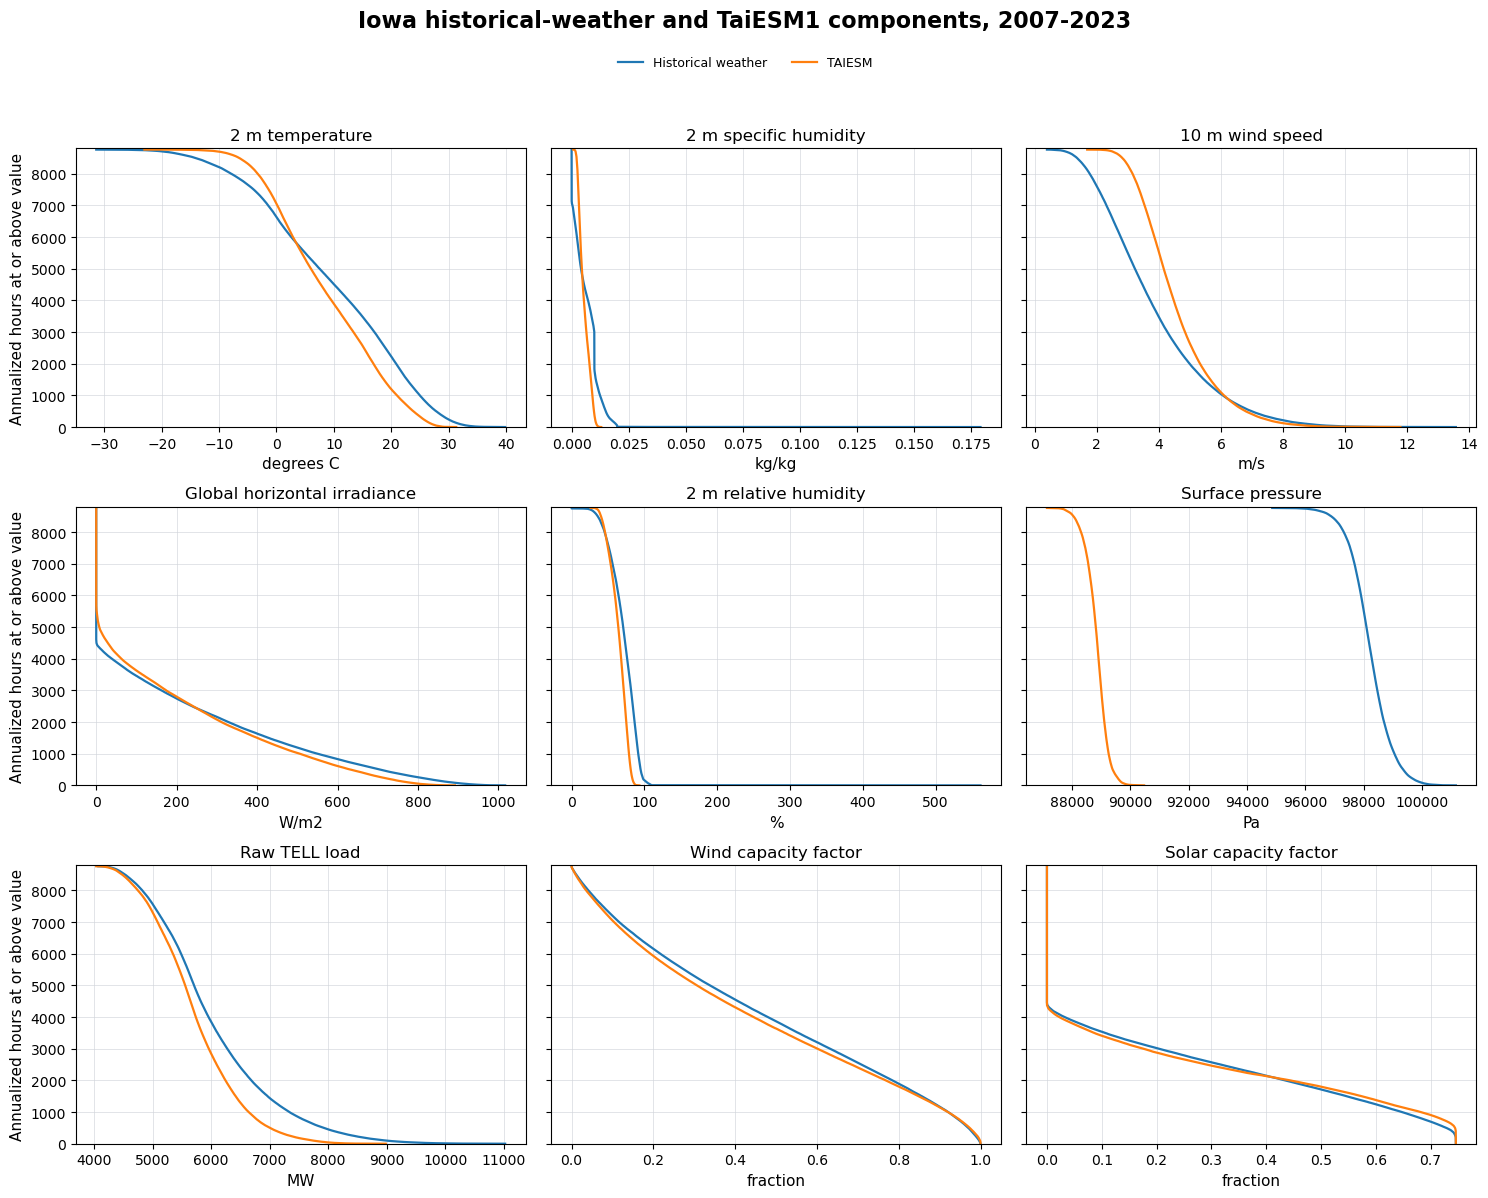

In [6]:
# Shared appearance for this notebook's figures.

colors = {"Historical weather": "#1f77b4", "TAIESM": "#ff7f0e"}
products = {"Historical weather": historical, "TAIESM": taiesm}

ranked_hours = np.arange(1, EXPECTED_HOURS + 1)
annualized_exceedance_hours = ranked_hours / ANALYSIS_YEARS

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
for panel_index, (ax, component) in enumerate(zip(axes.flat, COMPONENTS)):
    for product, frame in products.items():
        component_values = frame[component].to_numpy(dtype=float)
        sorted_values = np.sort(component_values)
        ordered = sorted_values[::-1]
        ax.plot(
            ordered,
            annualized_exceedance_hours,
            color=colors[product],
            linewidth=1.6,
            label=product,
        )

    ax.set_title(COMPONENT_LABELS[component])
    ax.set_xlabel(COMPONENT_UNITS[component])
    ax.set_ylim(0, 8_800)
    ax.grid(True)
    if panel_index % 3 == 0:
        ax.set_ylabel("Annualized hours at or above value")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle("Iowa historical-weather and TaiESM1 components, 2007-2023", y=0.995)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Interpretation

The diagnostic table quantifies differences in weather forcing and in the three
downstream energy components.

**Pressure discrepancy.** Mean pressure is 98,222.6 Pa in the historical
product and 88,853.2 Pa in TaiESM, a difference of -9,369.5 Pa. This difference
persists across the comparison years; it is not evidence that the products
agree simply because both series pass the timestamp and finite-value checks.

A separate check of the staged 2007 county inputs reconstructed both archived
Iowa series using the same 99 counties and 2020 population weights, with maximum
error below 0.000001 Pa. The aggregation applied no
factor-of-100 conversion to either staged pressure array. Thus the difference is present
before this notebook, in the staged source weather. The original HSDS metadata
and grid extraction were not revalidated because the service was unavailable;
the upstream cause remains unresolved. No pressure values or scientific methods
were changed during this cleanup.